## import libraries

In [323]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.decomposition import PCA
import umap
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import HDBSCAN
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import matplotlib.cm as cm
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist

## load embeddings

In [216]:
root_embeddings = "_data/exports/embeddings_exports"

In [259]:
def load_embeddings(folder, glob_pattern = "*.parquet"):
    dfs = []
    for path in Path(folder).glob(glob_pattern):
        stem = path.stem.replace("_embedding", "")
        *crop_parts, country, year = stem.split("_")
        df = pd.read_parquet(path)
        df["crop"] = "_".join(crop_parts)
        df["country"] = country
        df["year"] = int(year)
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

In [276]:
dataset = load_embeddings(root_embeddings)
dataset.head(3)

,tile_lon,tile_lat,pixel_row,pixel_col,crs,embedding,long_lat,crop,country_id,year,country
0,10.65,56.45,702.0,416.0,EPSG:32632,"[3.1441202, -0.40016073, 1.2004822, 2.1151354,...","[10.664917617831682, 56.43730676496256]",maize_corn_popcorn,dk,2019,dk
1,9.05,54.95,393.0,477.0,EPSG:32632,"[3.6699157, 0.42549747, 2.7125463, 4.7336593, ...","[9.07457125556681, 54.96468696472927]",maize_corn_popcorn,dk,2019,dk
2,9.25,55.55,1014.0,97.0,EPSG:32632,"[4.9585056, 0.7512887, -0.30051547, 1.8531787,...","[9.214983631495008, 55.508991389369086]",maize_corn_popcorn,dk,2019,dk


## check if embeddings are ok

In [277]:
def inspect_embedding_nulls(df, embedding_col="embedding"):
    col = df[embedding_col]
    print(f"Total rows:        {len(col)}")
    print(f"None:              {col.isna().sum()}")
    print(f"Scalar NaN:        {col.apply(lambda x: isinstance(x, float) and np.isnan(x)).sum()}")
    print(f"Array with NaN:    {col.apply(lambda x: isinstance(x, np.ndarray) and np.any(np.isnan(x))).sum()}")
    print(f"Empty list/array:  {col.apply(lambda x: hasattr(x, '__len__') and len(x) == 0).sum()}")
    
    bad = col[col.apply(lambda x: not isinstance(x, (np.ndarray, list)) or (hasattr(x, '__len__') and len(x) == 0))]
    print(f"\nSample bad values:\n{bad.head(5)}")
    print(f"\nTypes found: {col.apply(type).value_counts().to_dict()}")

In [278]:
inspect_embedding_nulls(dataset)

Total rows:        10000
None:              0
Scalar NaN:        0
Array with NaN:    7
Empty list/array:  0

Sample bad values:
Series([], Name: embedding, dtype: object)

Types found: {<class 'numpy.ndarray'>: 10000}


In [279]:
def filter_valid_embeddings(df, embedding_col="embedding"):
    valid_mask = df[embedding_col].apply(lambda x: np.all(np.isfinite(x.astype(np.float32))))
    n_dropped = (~valid_mask).sum()
    if n_dropped > 0:
        print(f"Dropping {n_dropped}/{len(df)} rows with NaN/Inf embeddings.")
    return df[valid_mask].reset_index(drop=True)

In [280]:
dataset = filter_valid_embeddings(dataset)
dataset.head(3)

Dropping 7/10000 rows with NaN/Inf embeddings.


,tile_lon,tile_lat,pixel_row,pixel_col,crs,embedding,long_lat,crop,country_id,year,country
0,10.65,56.45,702.0,416.0,EPSG:32632,"[3.1441202, -0.40016073, 1.2004822, 2.1151354,...","[10.664917617831682, 56.43730676496256]",maize_corn_popcorn,dk,2019,dk
1,9.05,54.95,393.0,477.0,EPSG:32632,"[3.6699157, 0.42549747, 2.7125463, 4.7336593, ...","[9.07457125556681, 54.96468696472927]",maize_corn_popcorn,dk,2019,dk
2,9.25,55.55,1014.0,97.0,EPSG:32632,"[4.9585056, 0.7512887, -0.30051547, 1.8531787,...","[9.214983631495008, 55.508991389369086]",maize_corn_popcorn,dk,2019,dk


## normalize embeddings

In [281]:
from sklearn.preprocessing import normalize
import numpy as np

# Stack embeddings into a 2D array, normalize, then store back
embeddings_matrix = np.vstack(dataset['embedding'].values)
dataset['norm_emb'] = list(normalize(embeddings_matrix, norm='l2'))

In [282]:
dataset.head(3)

,tile_lon,tile_lat,pixel_row,pixel_col,crs,embedding,long_lat,crop,country_id,year,country,norm_emb
0,10.65,56.45,702.0,416.0,EPSG:32632,"[3.1441202, -0.40016073, 1.2004822, 2.1151354,...","[10.664917617831682, 56.43730676496256]",maize_corn_popcorn,dk,2019,dk,"[0.103912964, -0.013225286, 0.03967586, 0.0699..."
1,9.05,54.95,393.0,477.0,EPSG:32632,"[3.6699157, 0.42549747, 2.7125463, 4.7336593, ...","[9.07457125556681, 54.96468696472927]",maize_corn_popcorn,dk,2019,dk,"[0.118547425, 0.013744629, 0.08762201, 0.15290..."
2,9.25,55.55,1014.0,97.0,EPSG:32632,"[4.9585056, 0.7512887, -0.30051547, 1.8531787,...","[9.214983631495008, 55.508991389369086]",maize_corn_popcorn,dk,2019,dk,"[0.16480146, 0.024969917, -0.009987966, 0.0615..."


## reduce embeddings

In [288]:
def reduce_embeddings(df, method, embedding_col="embedding", n_components=2):
    emb = np.stack(df[embedding_col].values)

    if method == "umap":
        reducer = umap.UMAP(n_components=2, 
                            n_neighbors=30, 
                            min_dist=0.1, 
                            metric='cosine', 
                            random_state=42)
    elif method == "pca":
        reducer = PCA(n_components=n_components)
    elif method == "tsne":
        reducer = TSNE(n_components=2, 
                       perplexity=50, 
                       learning_rate='auto', 
                       init='pca', 
                       metric='cosine', 
                       random_state=42)

    reduced = reducer.fit_transform(emb)

    result = df.copy()
    
    for i in range(n_components):
        result[f"dim_{i+1}"] = reduced[:, i]

    return result

In [289]:
dataset_pca = reduce_embeddings(dataset, 'pca')
dataset_umap = reduce_embeddings(dataset, 'umap')
dataset_tsne = reduce_embeddings(dataset, 'tsne')

/Users/devseed/Documents/docs/THESIS/SpatialTemporal_generalization_of_SITS_FM/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [290]:
dataset_pca_norm = reduce_embeddings(dataset, 'pca', embedding_col="norm_emb")
dataset_umap_norm = reduce_embeddings(dataset, 'umap', embedding_col="norm_emb")
dataset_tsne_norm = reduce_embeddings(dataset, 'tsne', embedding_col="norm_emb")

/Users/devseed/Documents/docs/THESIS/SpatialTemporal_generalization_of_SITS_FM/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [306]:
filtered_df = dataset_umap_norm[dataset_umap_norm["country"] == "ee"]

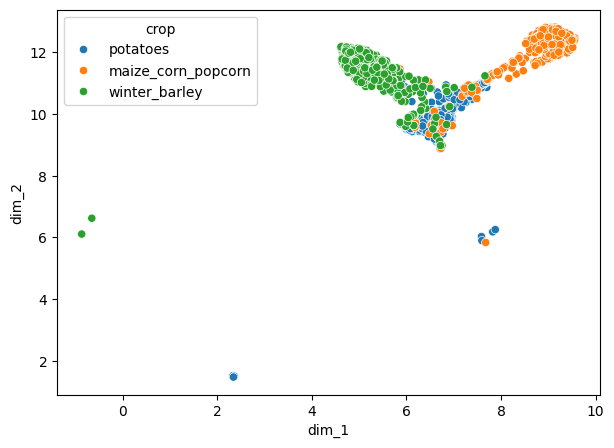

In [307]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=filtered_df, x="dim_1", y="dim_2", hue="crop")
plt.show()

## analysis

In [354]:
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns

def plot_similarity(df, emb_col, group_col):
    centroids = df.groupby(group_col)[emb_col].apply(
        lambda x: np.vstack(x.values).mean(axis=0)
    )
    labels = centroids.index.tolist()
    matrix = np.vstack(centroids.values)
    sim_df = pd.DataFrame(cosine_similarity(matrix), index=labels, columns=labels)
    
    plt.figure(figsize=(5, 4))
    sns.heatmap(sim_df, annot=True, fmt='.2f', cmap='RdYlGn', vmin=-1, vmax=1)
    plt.title(f'Cosine similarity — {group_col}')
    plt.tight_layout()
    plt.show()


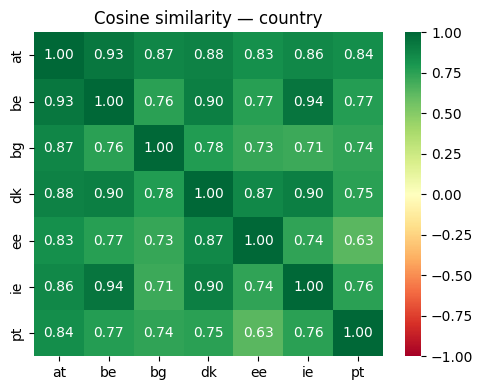

In [355]:
plot_similarity(dataset_umap_norm, 'norm_emb', 'country')

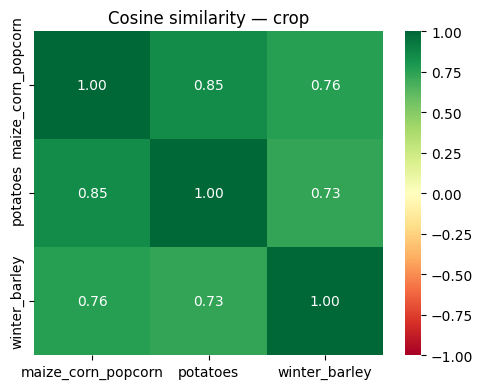

In [356]:
plot_similarity(dataset_umap_norm, 'norm_emb', 'crop')

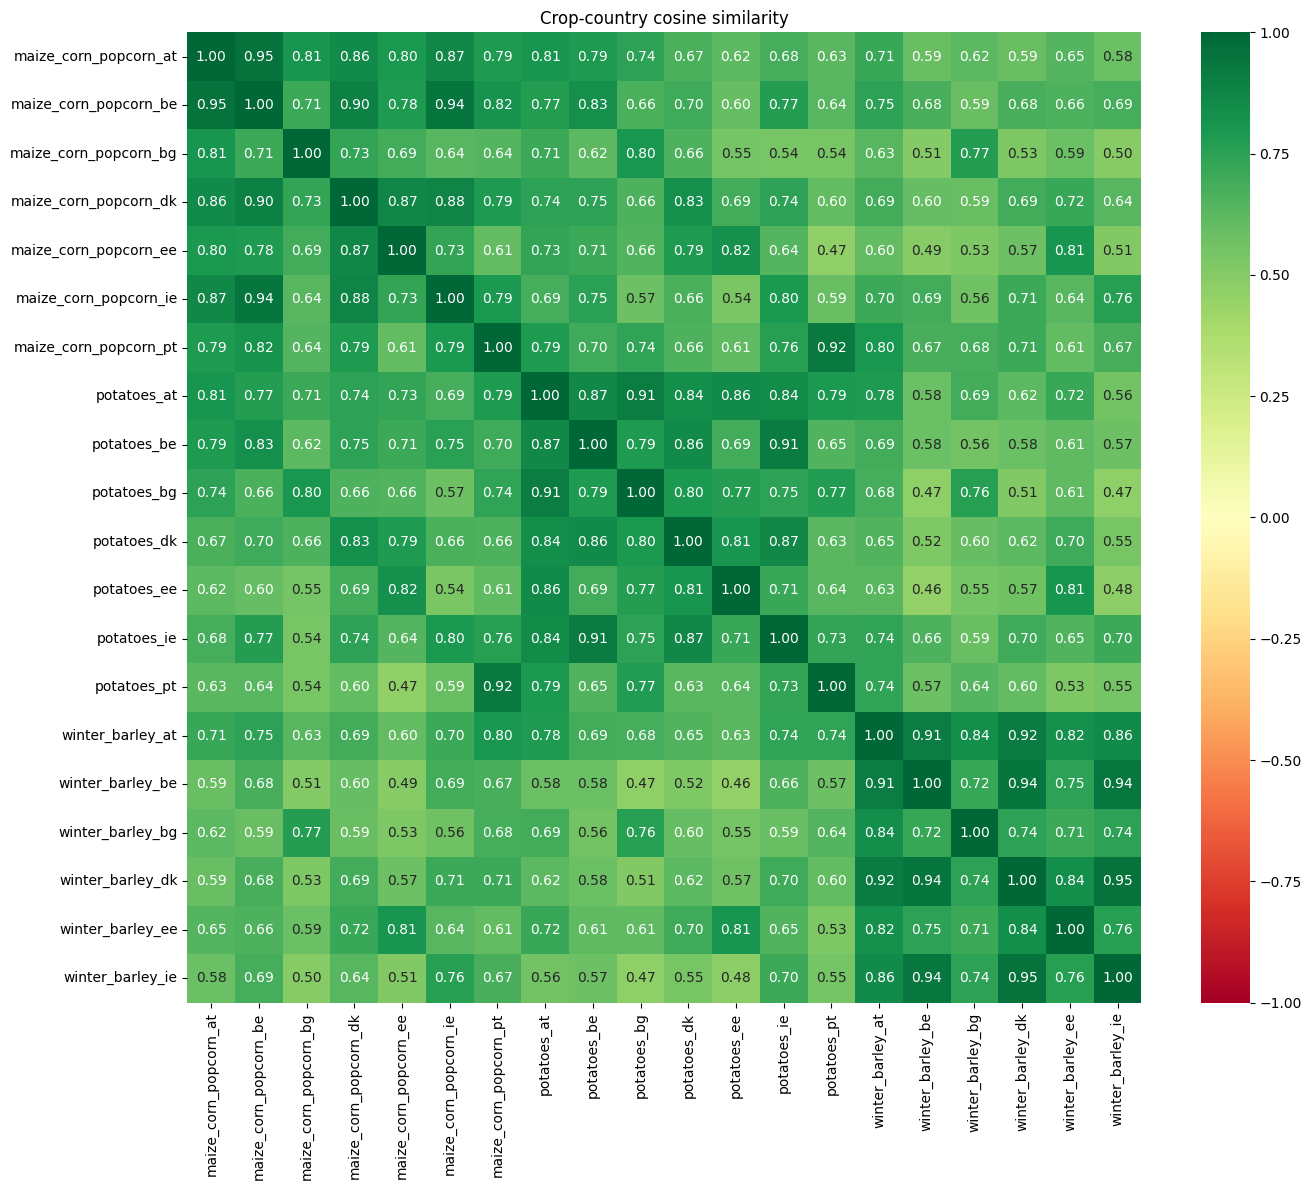

In [357]:
def plot_crop_country_similarity(df, emb_col):
    centroids = df.groupby(['crop', 'country'])[emb_col].apply(
        lambda x: np.vstack(x.values).mean(axis=0)
    )
    labels = [f"{crop}_{country}" for crop, country in centroids.index]
    matrix = np.vstack(centroids.values)
    sim_df = pd.DataFrame(cosine_similarity(matrix), index=labels, columns=labels)

    plt.figure(figsize=(14, 12))
    sns.heatmap(sim_df, annot=True, fmt='.2f', cmap='RdYlGn', vmin=-1, vmax=1)
    plt.title('Crop-country cosine similarity')
    plt.tight_layout()
    plt.show()

plot_crop_country_similarity(dataset_umap_norm, 'norm_emb')

In [358]:
def plot_map(df, group_col):
    coords = np.vstack(df['long_lat'].values)
    lons, lats = coords[:, 0], coords[:, 1]

    groups = df[group_col].unique()
    colors = cm.tab20(np.linspace(0, 1, len(groups)))
    color_map = dict(zip(groups, colors))

    fig, ax = plt.subplots(figsize=(12, 8))
    for grp, color in color_map.items():
        mask = df[group_col] == grp
        ax.scatter(lons[mask], lats[mask], label=grp, alpha=0.6, s=15, color=color)

    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title(f'Geographic distribution colored by {group_col}')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=2)
    plt.tight_layout()
    plt.show()

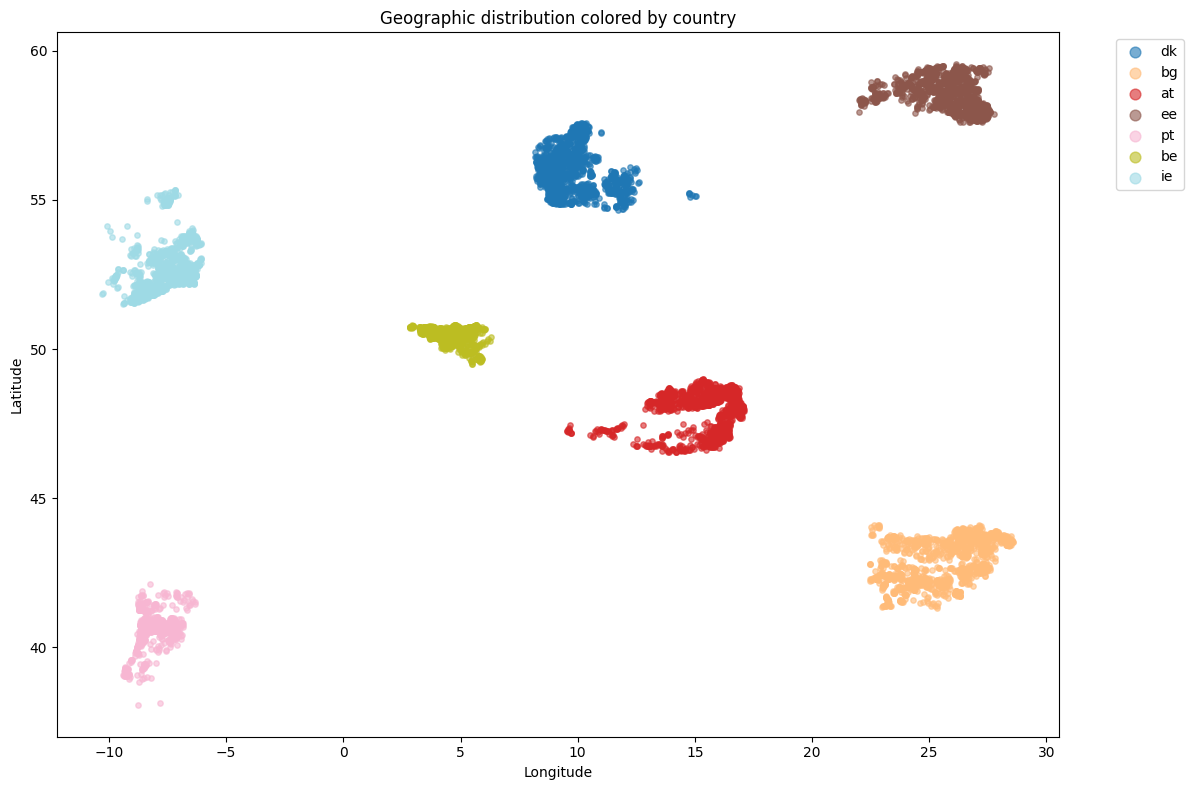

In [359]:
plot_map(dataset_umap_norm, 'country')

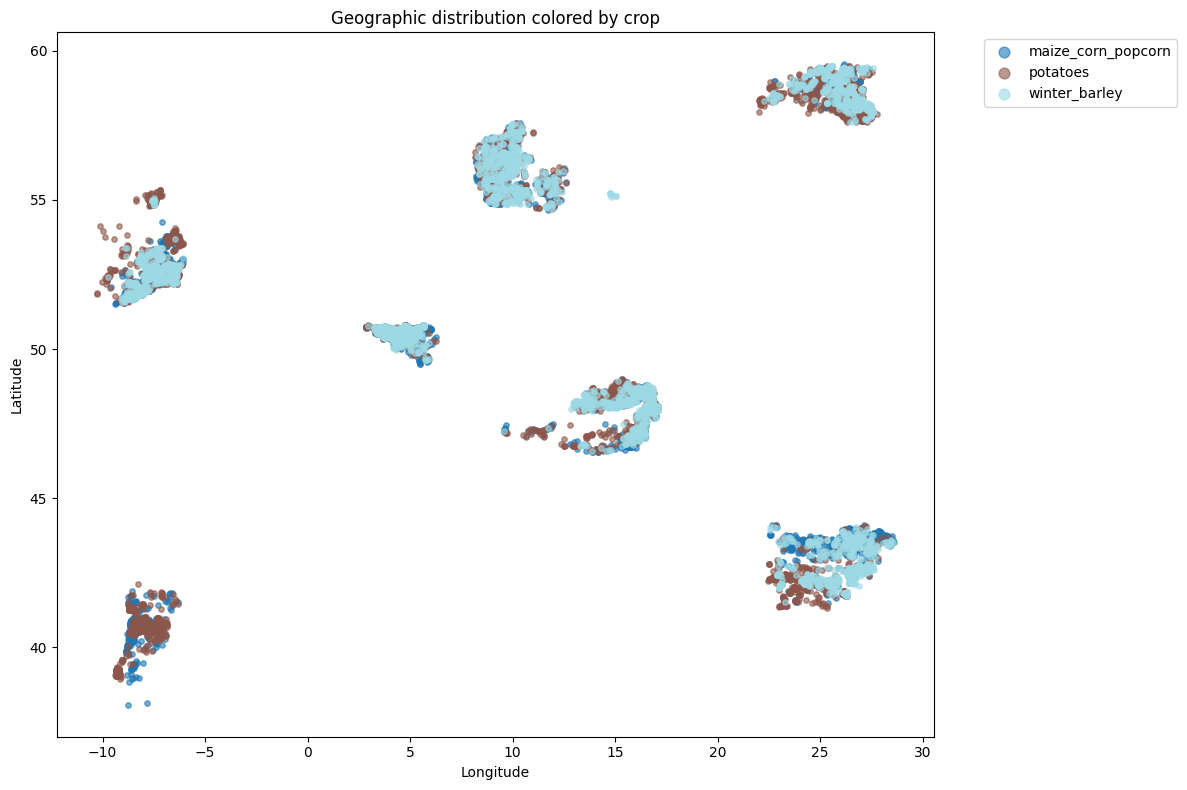

In [360]:
plot_map(dataset_umap_norm, 'crop')

In [361]:
def plot_umap_faceted(df, facet_col, color_col, x_col='dim_1', y_col='dim_2'):
    facets = sorted(df[facet_col].unique())
    groups = sorted(df[color_col].unique())
    colors = cm.tab20(np.linspace(0, 1, len(groups)))
    color_map = dict(zip(groups, colors))

    ncols = 3
    nrows = int(np.ceil(len(facets) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
    axes = axes.flatten()

    for i, facet in enumerate(facets):
        ax = axes[i]
        subset = df[df[facet_col] == facet]
        for grp in groups:
            mask = subset[color_col] == grp
            if mask.any():
                ax.scatter(subset.loc[mask, x_col], subset.loc[mask, y_col],
                           label=grp, alpha=0.5, s=10, color=color_map[grp])
        ax.set_title(facet, fontsize=10)
        ax.set_xlabel(x_col)
        ax.set_ylabel(y_col)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    handles = [plt.Line2D([0], [0], marker='o', color='w',
                           markerfacecolor=color_map[g], markersize=8, label=g)
               for g in groups]
    fig.legend(handles=handles, bbox_to_anchor=(1.02, 0.5),
               loc='center left', title=color_col)
    fig.suptitle(f'UMAP per {facet_col} — colored by {color_col}', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

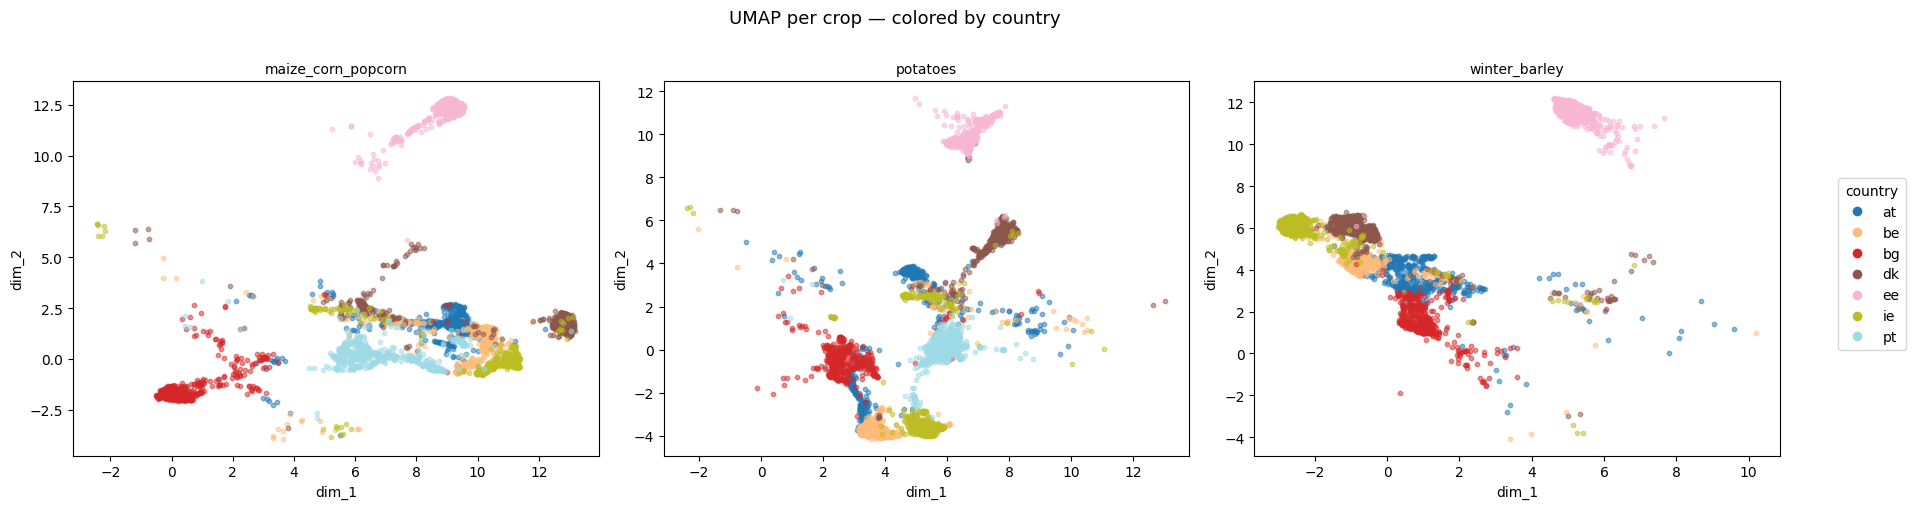

In [362]:
plot_umap_faceted(dataset_umap_norm, facet_col='crop', color_col='country')

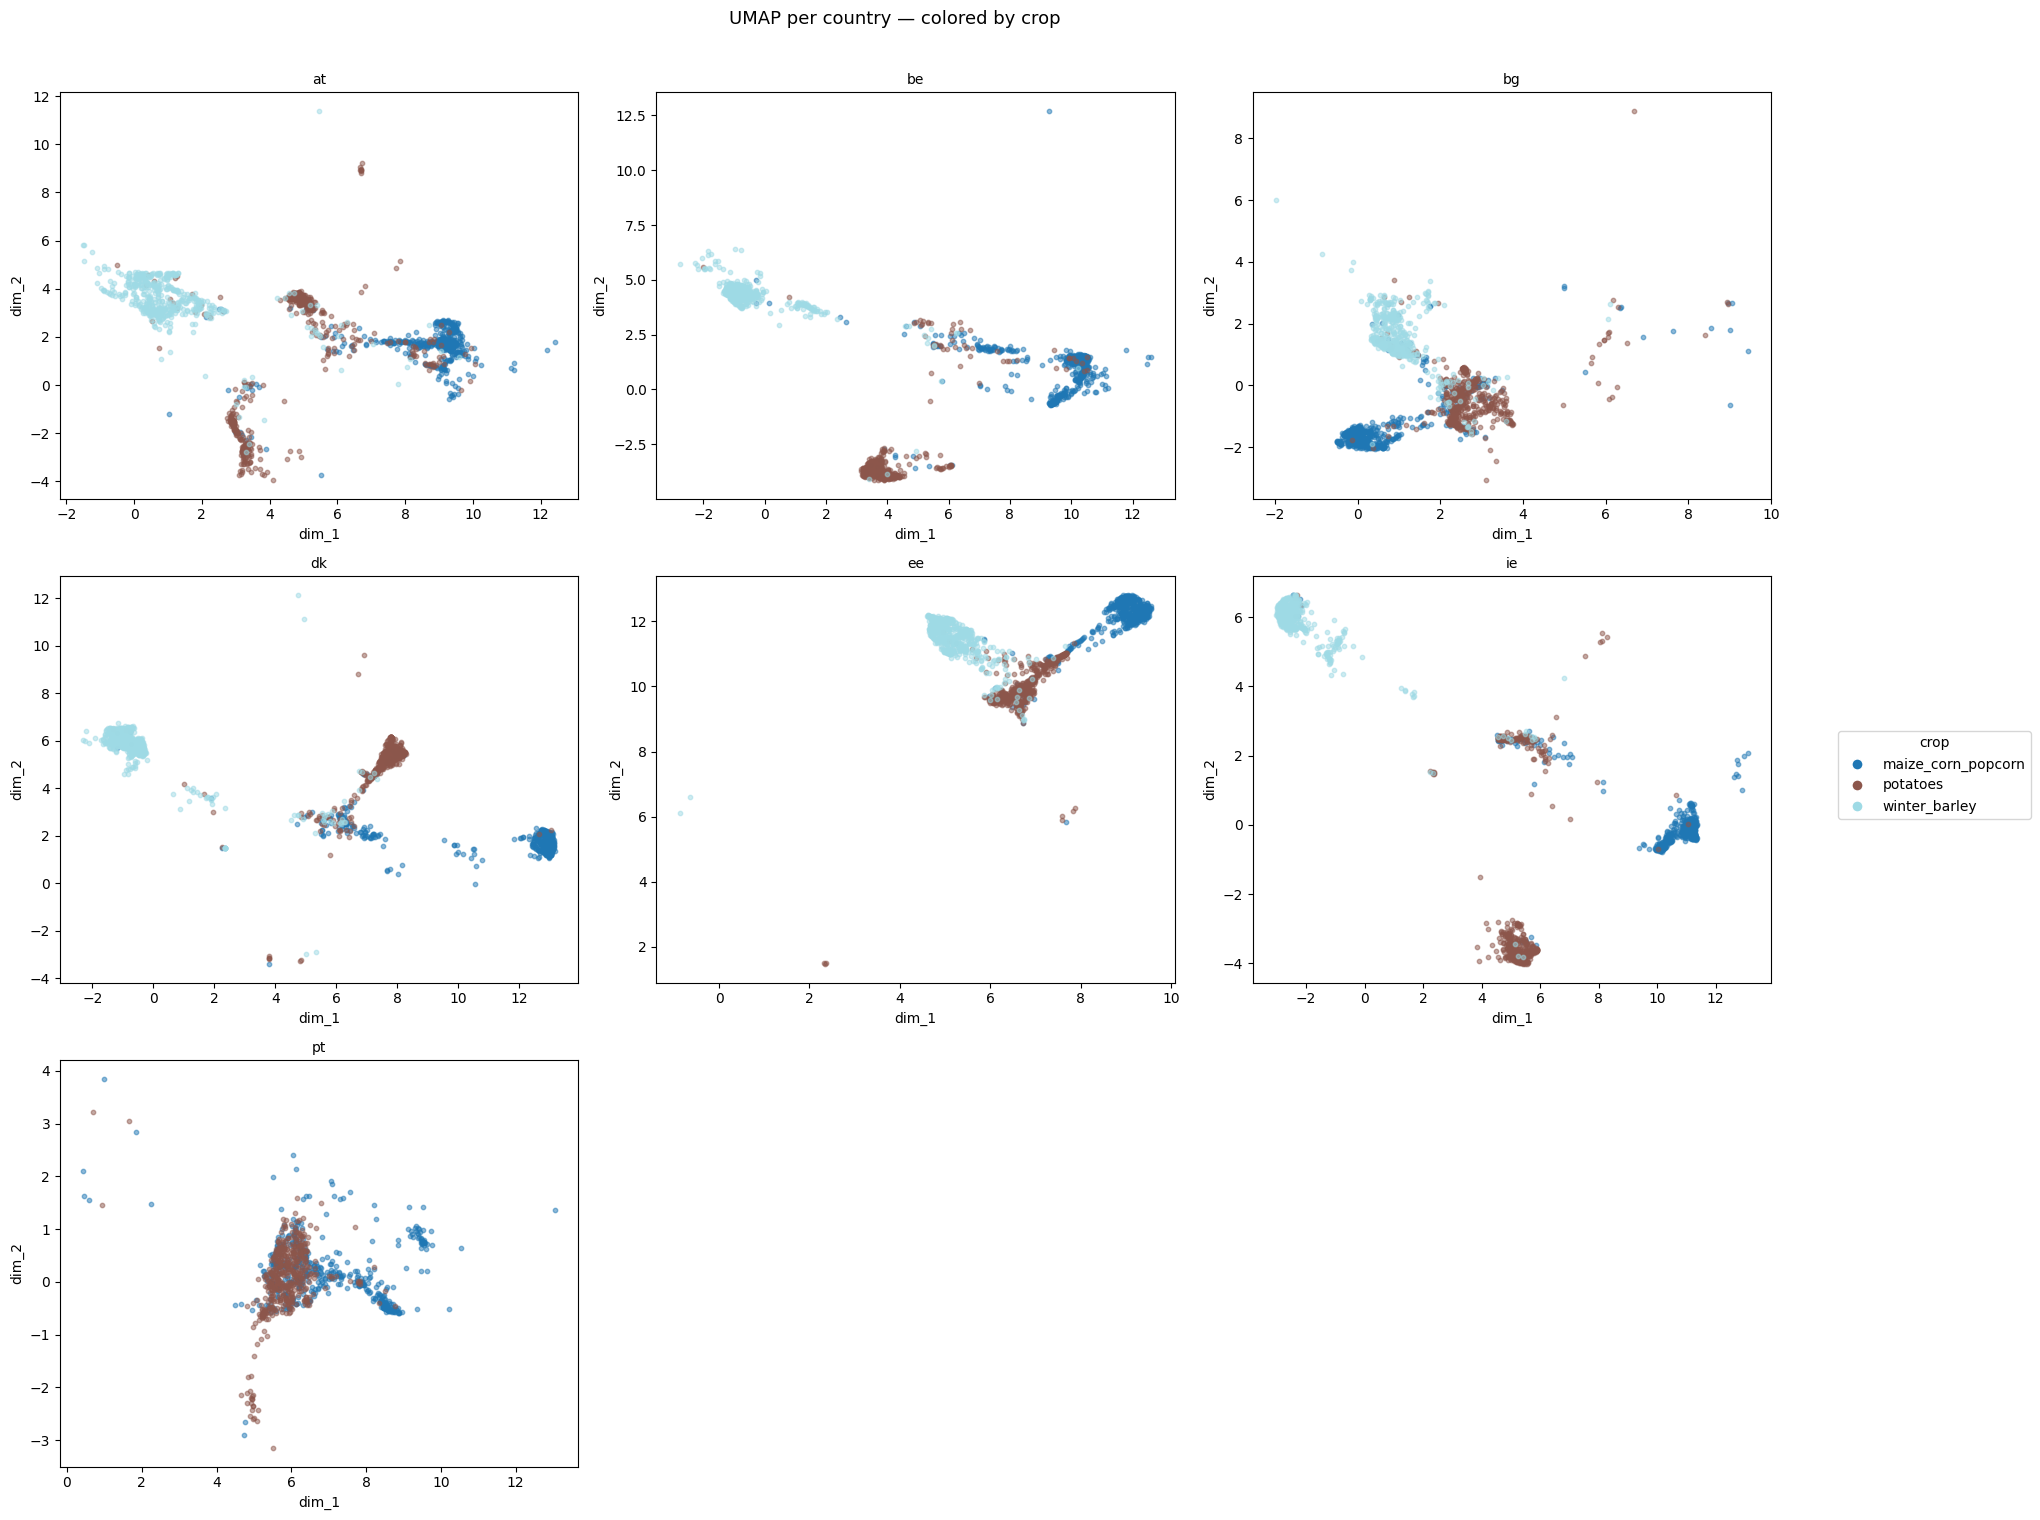

In [363]:
plot_umap_faceted(dataset_umap_norm, facet_col='country', color_col='crop')

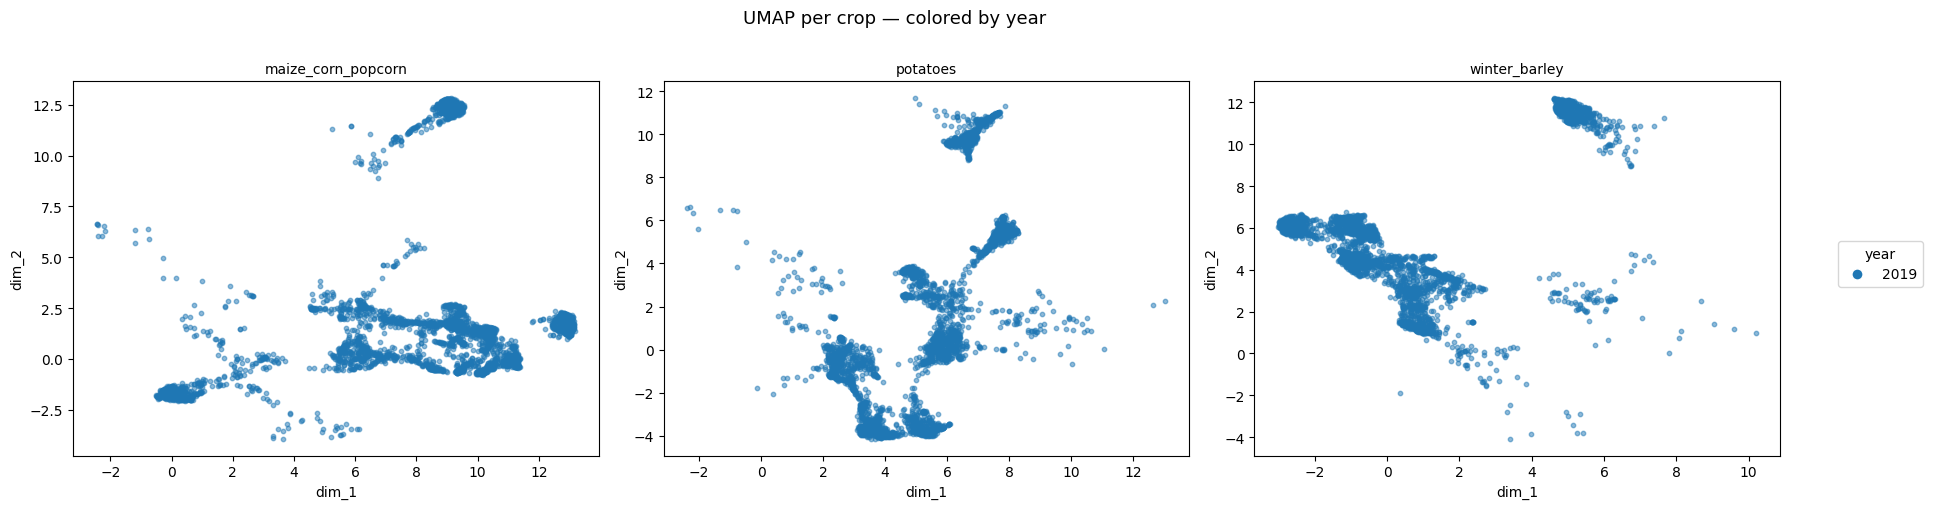

In [364]:
plot_umap_faceted(dataset_umap_norm, facet_col='crop', color_col='year')